<a href="https://colab.research.google.com/github/daveveed/Geo-Data-Science/blob/main/Workiing_with_map_projections.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os, geopandas as gpd, matplotlib.pyplot as plt
from pyproj import CRS
from shapely.geometry import Point

In [2]:
data_folder = 'data'
output_folder = 'output'

if not os.path.exists(data_folder):
    os.makedirs(data_folder)

if not os.path.exists(output_folder):
    os.makedirs(output_folder)

In [3]:
import requests

In [4]:
def downlaod(url):
  filename = os.path.join(data_folder, os.path.basename(url))

  if not os.path.exists(filename):
    response = requests.get(url, allow_redirects=True)

    with open(filename, 'wb') as f:
      f.write(response.content)
    print('downloaded', filename)


In [5]:
file_url = 'https://raw.githubusercontent.com/daveveed/Geo-Data-Science/main/Data/Temp/eu_countries_2022.gpkg'
downlaod(file_url)

downloaded data/eu_countries_2022.gpkg


In [6]:
data_fp = os.path.join(data_folder, 'eu_countries_2022.gpkg')
data = gpd.read_file(data_fp)
data.head()

,CNTR_ID,CNTR_NAME,NAME_ENGL,NAME_FREN,ISO3_CODE,SVRG_UN,CAPT,EU_STAT,EFTA_STAT,CC_STAT,NAME_GERM,geometry
0,IT,Italia,Italy,Italie,ITA,UN Member State,Rome,T,F,F,Italien,"MULTIPOLYGON (((13.684 46.4375, 13.511 46.3484..."
1,BE,Belgien-Belgique-België,Belgium,Belgique,BEL,UN Member State,Brussels,T,F,F,Belgien,"MULTIPOLYGON (((6.3156 50.497, 6.405 50.3233, ..."
2,BG,България,Bulgaria,Bulgarie,BGR,UN Member State,Sofia,T,F,F,Bulgarien,"MULTIPOLYGON (((28.498 43.4341, 28.0602 43.316..."
3,AT,Österreich,Austria,Autriche,AUT,UN Member State,Vienna,T,F,F,Österreich,"MULTIPOLYGON (((16.9498 48.5358, 16.8511 48.43..."
4,CY,Κύπρος-Kıbrıs,Cyprus,Chypre,CYP,UN Member State,Nicosia,T,F,F,Zypern,"MULTIPOLYGON (((32.9417 34.6418, 32.559 34.687..."


In [7]:
data.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

However, WGS84 is not really a good coordinate system for representing European borders on a map because the areas get distorted, especially towards the North pole. Hence, it is a good idea to convert these geometries into Lambert Azimuthal Equal Area projection (EPSG:3035) which is a good option for creating maps with country-level data in Europe.

## Reprojecting a GeoDataFrame

In [8]:
data_wgs84 = data.copy() #back up data

data = data.to_crs(epsg=3035) #reprojected data

data.crs.to_epsg() #checking if it has been reprojected

3035

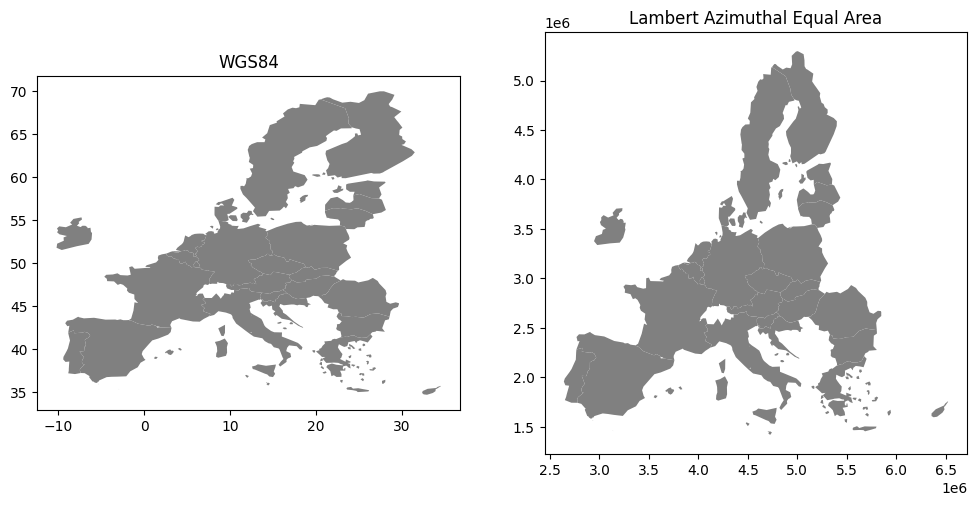

In [11]:
fig, ax = plt.subplots(1, 2)
fig.set_size_inches(12, 12)

#plot data in wgs 84
data_wgs84.plot(ax=ax[0],
          facecolor='grey')
#plot data in projected coord
data.plot(ax=ax[1],
          facecolor='grey')

ax[0].set_title('WGS84')
ax[1].set_title('Lambert Azimuthal Equal Area')

ax[0].set_aspect(aspect=1)
ax[1].set_aspect(aspect=1)

plt.show()

In [12]:
ouput_fn = 'EU_boarders_2022_EPSG3035.shp'
output_fp = os.path.join(output_folder, ouput_fn)
data.to_file(output_fp)

## Parsing Coordinate Reference System characteristics

In [14]:
crs_object = CRS.from_epsg(3035)
type(crs_object)
crs_object

<Projected CRS: EPSG:3035>
Name: ETRS89-extended / LAEA Europe
Axis Info [cartesian]:
- Y[north]: Northing (metre)
- X[east]: Easting (metre)
Area of Use:
- name: Europe - European Union (EU) countries and candidates. Europe - onshore and offshore: Albania; Andorra; Austria; Belgium; Bosnia and Herzegovina; Bulgaria; Croatia; Cyprus; Czechia; Denmark; Estonia; Faroe Islands; Finland; France; Germany; Gibraltar; Greece; Hungary; Iceland; Ireland; Italy; Kosovo; Latvia; Liechtenstein; Lithuania; Luxembourg; Malta; Monaco; Montenegro; Netherlands; North Macedonia; Norway including Svalbard and Jan Mayen; Poland; Portugal including Madeira and Azores; Romania; San Marino; Serbia; Slovakia; Slovenia; Spain including Canary Islands; Sweden; Switzerland; Türkiye (Turkey); United Kingdom (UK) including Channel Islands and Isle of Man; Vatican City State.
- bounds: (-35.58, 24.6, 44.83, 84.73)
Coordinate Operation:
- name: Europe Equal Area 2001
- method: Lambert Azimuthal Equal Area
Datum: Eur

In [15]:
print("Name:", crs_object.name)
print("Coordinate system:", crs_object.coordinate_system)
print("Bounds:", crs_object.area_of_use.bounds)
print("Datum:", crs_object.datum)

Name: ETRS89-extended / LAEA Europe
Coordinate system: cartesian
Bounds: (-35.58, 24.6, 44.83, 84.73)
Datum: European Terrestrial Reference System 1989 ensemble


We can also easily export this CRS information to different formats, such as WKT or Proj4 text, or to EPSG code. For this, we can use the CRS class methods, such as .to_wkt(), .to_proj4() and .to_epsg() accordingly. You can explore all the possible information that can be extracted (and exported) from the CRS by typing crs_object. and pressing Tab. In the following, we export the CRS information to WKT format:

In [16]:
crs_wkt = crs_object.to_wkt()
print(crs_wkt)

PROJCRS["ETRS89-extended / LAEA Europe",BASEGEOGCRS["ETRS89",ENSEMBLE["European Terrestrial Reference System 1989 ensemble",MEMBER["European Terrestrial Reference Frame 1989"],MEMBER["European Terrestrial Reference Frame 1990"],MEMBER["European Terrestrial Reference Frame 1991"],MEMBER["European Terrestrial Reference Frame 1992"],MEMBER["European Terrestrial Reference Frame 1993"],MEMBER["European Terrestrial Reference Frame 1994"],MEMBER["European Terrestrial Reference Frame 1996"],MEMBER["European Terrestrial Reference Frame 1997"],MEMBER["European Terrestrial Reference Frame 2000"],MEMBER["European Terrestrial Reference Frame 2005"],MEMBER["European Terrestrial Reference Frame 2014"],MEMBER["European Terrestrial Reference Frame 2020"],ELLIPSOID["GRS 1980",6378137,298.257222101,LENGTHUNIT["metre",1]],ENSEMBLEACCURACY[0.1]],PRIMEM["Greenwich",0,ANGLEUNIT["degree",0.0174532925199433]],ID["EPSG",4258]],CONVERSION["Europe Equal Area 2001",METHOD["Lambert Azimuthal Equal Area",ID["EPSG",9

In [17]:
# Retrieve EPSG code from WKT text
epsg = CRS(crs_wkt).to_epsg()
print(epsg)

3035


##Defining CRS for a GeoDataFrame

In [19]:
gdf = gpd.GeoDataFrame({'geometry': Point(24.95, 60.169)}, index=[0])
print(gdf.crs)

None


As we see, the GeoDataFrame does not have CRS specified at this stage which is a problem, because the GIS systems cannot work with this kind of dataset. The coordinates for our point are represented in decimal degrees, hence the CRS of our GeoDataFrame should be WGS84. We can define the CRS for our data in a few different ways, but one of the approaches is to use the CRS.from_epsg() method from the pyproj library, and update the CRS information of the the GeoDataFrame with the .set_crs() method:

In [20]:
gdf = gdf.set_crs(epsg=4326)
print(gdf.crs)

EPSG:4326


In [21]:
# Create GeoDataFrame with one point and define the CRS
gdf = gpd.GeoDataFrame(geometry=[Point(24.950899, 60.169158)], crs="EPSG:4326")
gdf.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

##Defining different map projections

In [22]:
world_url = 'https://raw.githubusercontent.com/daveveed/Geo-Data-Science/main/Data/Temp/ne_110m_admin_0_countries.zip'
downlaod(world_url)

downloaded data/ne_110m_admin_0_countries.zip


In [23]:
world_fp = os.path.join(data_folder, 'ne_110m_admin_0_countries.zip')
world = gpd.read_file(world_fp)
world.head()

,featurecla,scalerank,LABELRANK,SOVEREIGNT,SOV_A3,ADM0_DIF,LEVEL,TYPE,TLC,ADMIN,...,FCLASS_TR,FCLASS_ID,FCLASS_PL,FCLASS_GR,FCLASS_IT,FCLASS_NL,FCLASS_SE,FCLASS_BD,FCLASS_UA,geometry
0,Admin-0 country,1,6,Fiji,FJI,0,2,Sovereign country,1,Fiji,...,None,None,None,None,None,None,None,None,None,"MULTIPOLYGON (((180 -16.06713, 180 -16.55522, ..."
1,Admin-0 country,1,3,United Republic of Tanzania,TZA,0,2,Sovereign country,1,United Republic of Tanzania,...,None,None,None,None,None,None,None,None,None,"POLYGON ((33.90371 -0.95, 34.07262 -1.05982, 3..."
2,Admin-0 country,1,7,Western Sahara,SAH,0,2,Indeterminate,1,Western Sahara,...,Unrecognized,Unrecognized,Unrecognized,None,None,Unrecognized,None,None,None,"POLYGON ((-8.66559 27.65643, -8.66512 27.58948..."
3,Admin-0 country,1,2,Canada,CAN,0,2,Sovereign country,1,Canada,...,None,None,None,None,None,None,None,None,None,"MULTIPOLYGON (((-122.84 49, -122.97421 49.0025..."
4,Admin-0 country,1,2,United States of America,US1,1,2,Country,1,United States of America,...,None,None,None,None,None,None,None,None,None,"MULTIPOLYGON (((-122.84 49, -120 49, -117.0312..."


In [24]:
world.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

Text(0.5, 1.0, 'WGS84')

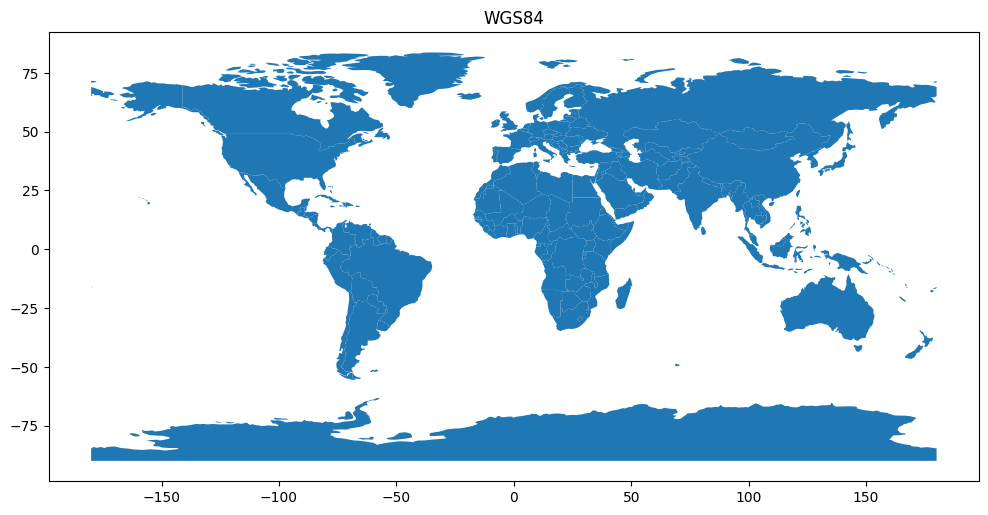

In [26]:
# Plot in original crs
world.plot(figsize=(12, 6))
plt.title("WGS84")

As we can see, the source data is in WGS84 projection which distorts the shape of the countries quite a bit especially in the Northern and Southern parts of the world. We can easily reproject the data into Web Mercator which is widely used in Web mapping applications. We can do this by using the .to_crs() method and plotting the result (in this case as an interactive map):

In [29]:
world.to_crs(epsg=3857).explore()

As we can see, the Web Mercator projection also distorts and exaggerates e.g. the size of the Antarctica and Greenland quite significantly. Luckily, there are also better map projections for visualizing global datasets, such as Eckert IV. There isn’t a direct EPSG number for Eckert IV, but we can provide the CRS information as an ESRI CRS code ESRI:54012 as follows:

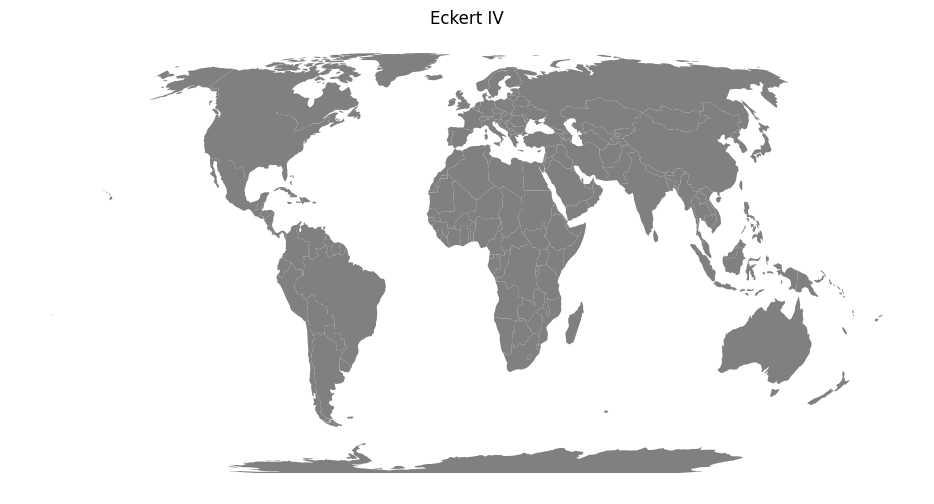

In [40]:
world.to_crs(crs='ESRI:54012').plot(figsize=(12, 6), facecolor='grey')
plt.title("Eckert IV")
plt.axis('off')

plt.savefig(os.path.join(output_folder, 'Eckert_IV.png'), dpi=150)
plt.show()

As the Figure shows, the Eckert IV map projection provides a more balanced view of the world with less distortion in the Northern and Southern parts of the world. Lastly, we can also define an Orthographic projection for our map which can be centered to specific point in the world. For doing this, we can specify the CRS using a proj-string and specify the center point with a few of CRS parameters: +lat, +lon



/usr/local/lib/python3.12/dist-packages/shapely/constructive.py:829: RuntimeWarning: invalid value encountered in normalize
  return lib.normalize(geometry, **kwargs)


Text(0.5, 1.0, 'Orthographic')

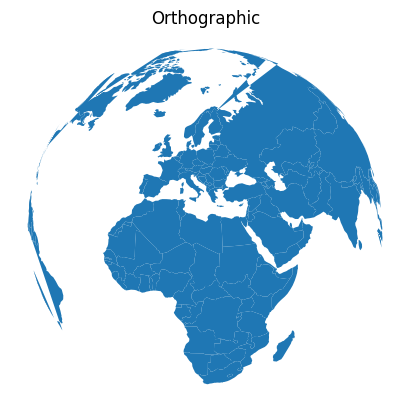

In [34]:
proj_string = "+proj=ortho +lat_0=29.00 +lon_0=19.0000"
world.to_crs(crs=proj_string).plot()
plt.axis("off")
plt.title("Orthographic")